# 2 — Score patches and reconstruct maps

Rates every patch of one dataset on a 1–6 meaningfulness scale with a VLM (via
OpenRouter), reconstructs per-image AI meaning maps from those scores, optionally
applies center bias, and runs a quick correlation check.

Scores are cached by patch hash + prompt id, so re-running only queries patches
that have not been scored yet.

**API calls cost money** — test with `limit=` and double-check model, prompt and
dataset before launching a full run.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os

import pandas as pd

from src.meaningfulness import OpenRouterGeminiProvider, async_run_analysis

## 1. Score the patches

The VLM rates every patch in `data/{DATASET}/patches_orig/`. Results are written to
a Parquet file holding the patch name, score, optional reasoning and run metadata.
The patch name encodes the source image and patch coordinates, so scores map back
onto the scene.

In [2]:
# --- Dataset ---------------------------------------------------------------
# Active datasets: "P21_scegram", "HH25_indoor", "HH25_outdoor"
# "TEST" is a 2-scene set for cheap end-to-end smoke tests.
DATASET = "TEST"

# --- Model and prompt ------------------------------------------------------
# Available on OpenRouter (see https://openrouter.ai/models for pricing):
#   google/gemini-3-flash-preview     google/gemini-2.5-pro
#   google/gemini-2.5-flash           google/gemini-2.0-flash-001
#   google/gemma-4-31b-it             qwen/qwen2.5-vl-72b-instruct
#   openai/gpt-5-mini                 openai/gpt-5-nano
#   qwen/qwen3.5-27b                  qwen/qwen3.6-27b
custom_model     = "google/gemini-2.5-flash"
custom_prompt_id = "original"   # selects docs/original_prompt/{id}.txt
reason           = False        # ask the model to reason before rating

# --- Paths -----------------------------------------------------------------
# One scores parquet per (dataset, prompt); models accumulate inside it, keyed by
# the "model" column. The cache skips patches already scored for this
# model + prompt_id, so re-running is free.
patch_dir    = Path(f"data/{DATASET}/patches_orig")
prompt_file  = Path(f"docs/original_prompt/{custom_prompt_id}.txt")
results_file = Path(f"results/results_scores/results_{DATASET}_{custom_prompt_id}.parquet")

model_slug            = custom_model.split("/")[-1]
model_slug_and_prompt = f"{model_slug}_{custom_prompt_id}/"
output_dir            = os.path.join(f"results/results_maps/{DATASET}/", model_slug_and_prompt)

print(f"Dataset : {DATASET}")
print(f"Patches : {patch_dir}")
print(f"Model   : {custom_model} ({custom_prompt_id})")
print(f"Prompt  : {prompt_file}")
print(f"Scores  : {results_file}")
print(f"Maps    : {output_dir}")

Dataset : TEST
Patches : data\TEST\patches_orig
Model   : google/gemini-2.5-flash (original)
Prompt  : docs\original_prompt\original.txt
Scores  : results\results_scores\results_TEST_original.parquet
Maps    : results/results_maps/TEST/gemini-2.5-flash_original/


In [3]:
# The prompt text lives in docs/original_prompt/, keyed by prompt_id, so that it
# is version-controlled and shared rather than retyped per entry point.
#
# The exact text is hashed into every cached score. Editing it while keeping the
# same prompt_id makes async_run_analysis raise on the existing cache — give a
# reworded prompt a new id (and a new file) instead.
custom_prompt = prompt_file.read_text(encoding="utf-8")

# Reference images interleaved into the prompt at the quoted placeholders.
reference_imgs = [
    Path("docs/original_prompt/example_scene.png"),
    Path("docs/original_prompt/low_meaning_example1.png"),
    Path("docs/original_prompt/low_meaning_example2.png"),
    Path("docs/original_prompt/high_meaning_example1.png"),
    Path("docs/original_prompt/high_meaning_example2.png"),
]

print(f"Prompt  : {prompt_file} ({len(custom_prompt)} chars)")
print(f"Refs    : {len(reference_imgs)} reference images")
print(custom_prompt)

Prompt  : docs\original_prompt\original.txt (1418 chars)
Refs    : 5 reference images
The purpose of this study is to gain a better understanding of how people perceive
real-world visual scenes like this:

"example_scene.png" - Real-world visual scene example

You will be presented with a patch of larger real-world scenes like the one above. Your task will be to rate how "meaningful" you think this scene patch is.  
What do we mean by "meaningful"? We want you to assess how "meaningful" an image is based on how informative or recognizable you think it is. 
For example, here are two scene patches taken from the example scene above that would be very low meaning:

"low_meaning_example1.png" - Edge of sidewalk
"low_meaning_example2.png" - Sky above house

Without the example scene it would be difficult to recognize what either of these image patches are. 

And here are two example patches that would be very high meaning.

"high_meaning_example1.png" - Window and roof
"high_meaning_example

In [4]:
# API key: OPENROUTER_API_KEY if set, otherwise a local openroutkey.txt.
openrout_api_key = os.environ.get("OPENROUTER_API_KEY", "").strip()
if not openrout_api_key:
    openrout_api_key = Path("openroutkey.txt").read_text(encoding="utf-8").strip()

provider = OpenRouterGeminiProvider(api_key=openrout_api_key, model=custom_model)

# Add limit=10 for a cheap smoke test before the full run.
results = await async_run_analysis(
    image_dir=patch_dir,
    provider=provider,
    max_concurrent=200,
    rate_limit=20.0,
    batch_size=100,
    output_path=results_file,
    include_reasoning=reason,
    prompt=custom_prompt,
    prompt_id=custom_prompt_id,
    temperature=0.0,
    reference_images=reference_imgs,
)

df = pd.read_parquet(results_file)
df

2026-08-25 20:14:07,135 - INFO - Reusing results for 0 identical patches, processing 336 new images with prompt_id: original
2026-08-25 20:14:07,137 - INFO - Processing 336 images with prompt_id: original
2026-08-25 20:14:07,137 - INFO - Processing first image in a blocking fashion to ensure prompt caching and save money
2026-08-25 20:14:15,182 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-08-25 20:14:15,212 - INFO - OpenRouter response: CompletionUsage(completion_tokens=143, prompt_tokens=1835, total_tokens=1978, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, reasoning_tokens=128, rejected_prediction_tokens=None, image_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=1459, cache_write_tokens=1459, video_tokens=0), cost=0.0010733533333333334, is_byok=False, cost_details={'upstream_inference_cost': 0.0010733533333333334, 'upstream_inference_prompt_cost

,image_path,image_hash,timestamp,score,model,prompt_content,prompt_id,reasoning,confidence
0,data\TEST\patches_orig\image01_w688_h524_x102_...,6907acbba2bed658b58aebded281ed3d1ed2540e1ce156...,2026-08-25 20:14:15.213889,2.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
1,data\TEST\patches_orig\image01_w688_h524_x102_...,0f778df2dcde5b24f98c8a6df23c1926c07aed03b5d7c8...,2026-08-25 20:14:17.698119,3.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
2,data\TEST\patches_orig\image01_w688_h524_x102_...,1f0307e7b8934e7bbb8d8868c4978bb07ecd83a7624d4c...,2026-08-25 20:14:34.975753,4.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
3,data\TEST\patches_orig\image01_w688_h524_x102_...,a675b85cc116d08d1cf289d5fabf92bf79320407b80ea1...,2026-08-25 20:14:32.515569,4.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
4,data\TEST\patches_orig\image01_w688_h524_x102_...,2977d094a07cfa12c33e3f8a86ac5743525b8fa5d69573...,2026-08-25 20:14:38.865740,3.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
...,...,...,...,...,...,...,...,...,...
331,data\TEST\patches_orig\image02_w688_h524_x83_y...,bc410b1a7bbdafee1a3324d87513eab2c423c6215722a7...,2026-08-25 20:16:08.192405,4.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
332,data\TEST\patches_orig\image02_w688_h524_x83_y...,2dd0f12b078a244b28a73416010f960dbd0b02c5dfdd26...,2026-08-25 20:16:10.182364,3.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
333,data\TEST\patches_orig\image02_w688_h524_x83_y...,99cbc05d798adc0bcb6f5266e80195ec914a6098c5cb59...,2026-08-25 20:16:09.773625,3.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None
334,data\TEST\patches_orig\image02_w688_h524_x83_y...,bcaa83851bdaae6902cce37d7a5ef1e0db064f7630eaf9...,2026-08-25 20:16:06.383684,2.0,google/gemini-2.5-flash,The purpose of this study is to gain a better ...,original,None,None


## 2. Reconstruct meaning maps

Averages overlapping patch scores per radius, then across radii, into one map per
scene. Written to `{output_dir}/maps_combined_raw/` as `.npy` and `.png`
(same data; the `.png` is a per-image min–max normalised preview only).

In [5]:
from src.patch_reconstruction25 import reconstruct_images

df = pd.read_parquet(results_file)

combined_maps_dir = os.path.join(output_dir, "maps_combined_raw")
print(f"Writing maps to: {combined_maps_dir}")

combined_maps = reconstruct_images(
    df, "score", combined_maps_dir, custom_model, custom_prompt_id, shape="round"
)

Writing maps to: results/results_maps/TEST/gemini-2.5-flash_original/maps_combined_raw
Processing 336 patches for model 'google/gemini-2.5-flash', prompt 'original'
Found 2 unique images
Processing image01...
  Image size: 688x524, radii: [np.int64(53), np.int64(123)]
  Radius 53: 120 patches, 360512/360512 pixels covered
  Radius 123: 48 patches, 360512/360512 pixels covered
  Saved image01.npy / .png  (values 2.000–6.000)
Processing image02...
  Image size: 688x524, radii: [np.int64(53), np.int64(123)]
  Radius 53: 120 patches, 360512/360512 pixels covered
  Radius 123: 48 patches, 360512/360512 pixels covered
  Saved image02.npy / .png  (values 2.750–6.000)


## 3. Apply center bias (optional)

Writes a center-biased copy of the maps to `{output_dir}/maps_combined_cb/`.
Only needed for datasets analysed in the `cb` condition.

In [ ]:
from src.patch_reconstruction25 import apply_center_bias

apply_center_bias(
    input_dir=os.path.join(output_dir, "maps_combined_raw"),
    output_dir=os.path.join(output_dir, "maps_combined_cb"),
)

## 4. Quick check

Per-image Pearson correlation between the new AI meaning maps and the human
meaning maps — a sanity check on the run, not a paper figure (those live in
`3_paper_plots.ipynb`). Uncomment entries in `select_maps` to add fixation or
saliency maps.

Images     : data/TEST/images
Comparison : results/results_comparisons/TEST/gemini-2.5-flash_original/
SaliencyComparator initialized successfully
Image directory: data/TEST/images
Map types: ['deepgaze', 'original']
Loading 2 common images...
Successfully loaded data for 2 images
Data loaded for 2 images
Computing pearson correlations with histogram_match=False, aggregation=median...
Applying Gaussian smoothing (sigma=15) before correlation, excluding ['fixation']
Correlations computed for 2 images using median
Saved correlation matrix to results/results_comparisons/TEST/gemini-2.5-flash_original/correlation_matrix.png


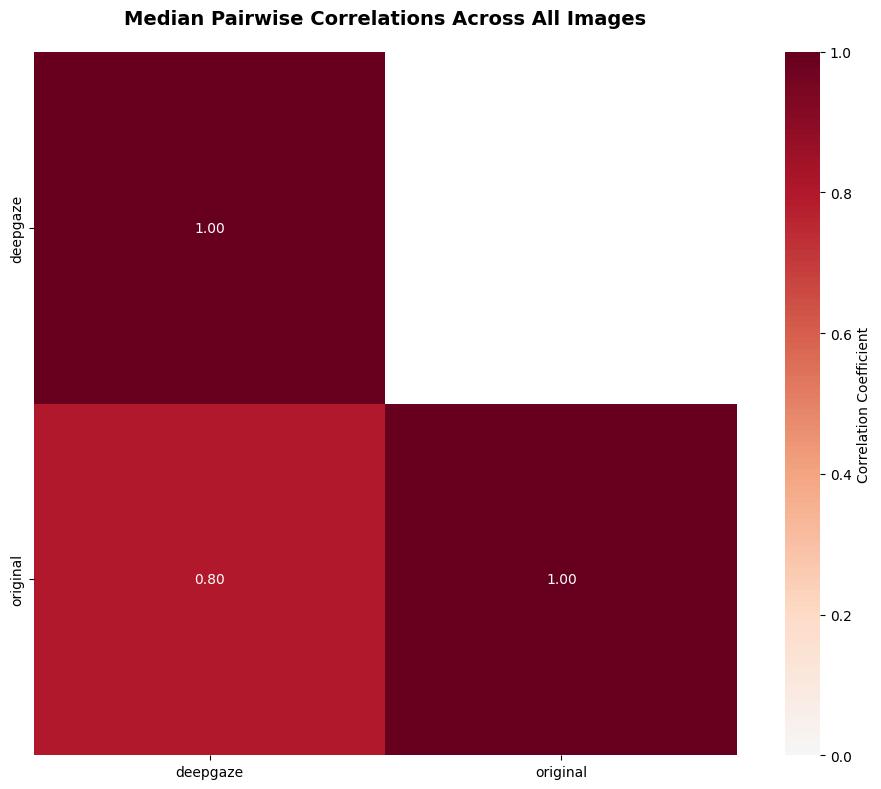

In [6]:
from src.map_comparison import SaliencyComparator

image_dir   = f"data/{DATASET}/images"
output_comp = os.path.join(f"results/results_comparisons/{DATASET}/", model_slug_and_prompt)
os.makedirs(output_comp, exist_ok=True)

select_maps = {
    # "fixation": f"data/{DATASET}/maps/fixation",   # keep first if histogram matching
    # "aws":      f"data/{DATASET}/maps/aws_ncb",
    # "gbvs":     f"data/{DATASET}/maps/gbvs_ncb",
    "deepgaze": f"data/{DATASET}/maps/deepgaze_ncb",
    # "mm": f"data/{DATASET}/maps/meaning_ncb",
}
select_maps[custom_prompt_id] = os.path.join(output_dir, "maps_combined_raw/")

# sigma=15 replicates Hayes & Henderson (2025); None disables smoothing.
# Fixation maps are already smoothed density estimates, so they are excluded.
SMOOTHING_SIGMA = 15
EXCLUDE_FROM_SMOOTHING = ["fixation"]

print(f"Images     : {image_dir}")
print(f"Comparison : {output_comp}")

comparator = SaliencyComparator(image_dir=image_dir, map_configs=select_maps)
comparator.load_data()
comparator.compute_correlations(
    histogram_match=False,
    aggregation_method="median",
    smoothing_sigma=SMOOTHING_SIGMA,
    exclude_from_smoothing=EXCLUDE_FROM_SMOOTHING,
)

comparator.plot_correlation_matrix(save_path=os.path.join(output_comp, "correlation_matrix.png"))
# comparator.export_results(output_comp)